# Notebook para pruebas de train en Colab

## Inicialización

In [ ]:
# Importación de librerías
# Gestión de archivos y reporte
import os
import shutil
import logging
import yaml

# Manipulación y análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Procesamiento de imágenes
from PIL import Image

# Machine Learning
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

### Carga de datos almacenados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cargar variables desde el archivo YAML
try:
    # Verificar si el archivo YAML existe
    yaml_filename = "constants.yaml"
    with open(yaml_filename, "r") as yaml_file:
        constants_data = yaml.safe_load(yaml_file)

    # Acceder a las variables
    ROOT_DIR = constants_data.get("ROOT_DIR")
    DATASET_PATH = constants_data.get("DATASET_PATH")
    SPLITTED_PATH = constants_data.get("SPLITTED_PATH")

    print(f"✅ Se han cargado las variables de configuración desde '{yaml_filename}'")
    print(f" - ROOT_DIR: {ROOT_DIR}")
    print(f" - DATASET_PATH: {DATASET_PATH}")
    print(f" - SPLITTED_PATH: {SPLITTED_PATH}")
except FileNotFoundError:
    print(f"Error: El archivo 'constants.yaml' no se encontró en la ubicación actual: {os.getcwd()}")
    print("Se creará nuevamente al correr el notebook.")
    ROOT_DIR = None
    DATASET_PATH = None
    SPLITTED_PATH = None
except Exception as e:
    print(f"Ocurrió un error al leer el archivo YAML: {e}")

Error: El archivo 'constants.yaml' no se encontró en la ubicación actual: /content
Se creará nuevamente al correr el notebook.


### Funciones necesarias

In [ ]:
import os, re

# Busca la carpeta raíz del dataset en el directorio donde fue descargado
def find_path(folder):
    match = re.search(fr"^(.*?)/{folder}/", DATASET_PATH)
    if match:
        prefix = match.group(1)
        path = os.path.join(prefix, f"{folder}/")
        return path
    else:
        print(f'No se ha podido encontrar la carpeta "{folder}" en {DATASET_PATH}')
        return None

In [ ]:
# Carga de imagenes en memoria y visualización
def load_image(data: pd.DataFrame, index: int, root: str=ROOT_DIR):
    """
    Carga una imagen PIL desde una fila específica de un DataFrame.

    Args:
        dataframe (pandas.DataFrame): El DataFrame que contiene las rutas de las imágenes.
        index (int): El índice de la fila en el DataFrame para cargar la imagen.
        root_dir (str): El directorio raíz donde se encuentran las imágenes.

    Returns:
        PIL.Image.Image: La imagen cargada como un objeto PIL.Image, o None si ocurre un error.
    """
    if index < 0 or index >= len(data):
        print("Índice fuera de rango.")
        return None

    row = data.iloc[index]
    relative_path = row['image_path']
    filename = row['filename']
    full_path = os.path.join(root, relative_path, filename)

    try:
        img = Image.open(full_path)
        return img
    except FileNotFoundError:
        print(f"Archivo no encontrado: {full_path}")
        return None
    except Exception as e:
        print(f"Error al cargar la imagen: {e}")
        return None

#### Descarga de dataset de Kaggle

In [ ]:
import kagglehub

# Download latest version
DATASET_PATH = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", DATASET_PATH)

Path to dataset files: /kaggle/input/plantvillage-dataset


In [ ]:
# Ruta de acceso al dataset
#/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented
ROOT_DIR = f'{DATASET_PATH}/plantvillage dataset/segmented'
# Opciones: color / grayscale / segmented

## Importación de imágenes

In [ ]:
# CONFIGURACIÓN INICIAL:
# Separador usado en los nombres de las subcarpetas
SEPARATOR = '___' # Separa entre 'group' y 'class'

# Extensiones de archivo de imagen a considerar (en minúsculas)
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp'}

# Configuración básica de logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [ ]:
def process_image_directory(root_dir, separator='___', valid_extensions=None):
    """
    Recorre un directorio raíz, extrae rutas de imágenes y metadatos de subcarpetas.

    Args:
        root_dir (str): La ruta al directorio raíz que contiene las subcarpetas de clases.
        separator (str): El separador utilizado en los nombres de las subcarpetas
                         para dividir 'group' y 'class'.
        valid_extensions (set, optional): Un conjunto de extensiones de archivo (en minúsculas,
                                          incluyendo el punto) a considerar como imágenes.
                                          Si es None, se usará un conjunto predeterminado.

    Returns:
        pandas.DataFrame: Un DataFrame con las columnas 'image_path', 'filename', 'group', 'class'.
                          Retorna un DataFrame vacío si el directorio raíz no existe o
                          no se encuentran imágenes válidas.
    """
    if valid_extensions is None:
        valid_extensions = IMAGE_EXTENSIONS # Verifica que sean archivos de imagen

    data = []
    output_columns = ['image_path', 'filename', 'class', 'group', 'tag'] # Define la estructura para el Dataframe

    if not os.path.isdir(root_dir):
        logging.error(f"El directorio raíz especificado no existe: {root_dir}")
        return pd.DataFrame(data, columns=output_columns) # Asegura que exista el directorio

    logging.info(f"Comenzando el procesamiento del directorio: {root_dir}")

    # Exploración de cada sucarpeta
    for entry in os.scandir(root_dir):
        if entry.is_dir():
            subdir_name = entry.name
            subdir_path = entry.path
            logging.info(f"Procesando subdirectorio: {subdir_name}")

            if separator in subdir_name:
                try:
                    group_name, tag = subdir_name.split(separator, 1)
                except ValueError:
                    logging.warning(f"No se pudo dividir el nombre '{subdir_name}' usando '{separator}'. Saltando directorio.")
                    continue

                for sub_entry in os.scandir(subdir_path):
                    if sub_entry.is_file():
                        file_name = sub_entry.name
                        file_path = sub_entry.path

                        _, extension = os.path.splitext(file_name)
                        if extension.lower() in valid_extensions:
                            relative_path = os.path.relpath(os.path.dirname(file_path), root_dir) # Carpeta dónde encontrar a imagen

                            # Almacena toda la información
                            data.append({
                                'image_path': f"{relative_path}/",
                                'filename': file_name,
                                'class': relative_path,
                                'group': group_name,
                                'tag': tag
                            })
                        else:
                            logging.debug(f"Archivo omitido (no es imagen válida): {file_path}")
            else:
                logging.warning(f"El nombre del subdirectorio '{subdir_name}' no contiene el separador '{separator}'. Saltando.")

    if not data:
        logging.warning("No se encontraron imágenes válidas en la estructura de directorios especificada.")

    # Construye el DataFrame
    df = pd.DataFrame(data, columns=output_columns)
    logging.info(f"Proceso completado. Se encontraron {len(df)} imágenes.")
    return df

In [ ]:
# Descomentar en caso de querer generarlo nuevamente el Dataframe
# del df

In [ ]:
# Verificación de importación de Dataframe del CSV
build_df = False # inicializa el estado

try:
    if df is None:
        # No se ha podido importar el CSV
        build_df = True
    else:
        # El Dataframe ya ha sido cargado en memoria
        build_df = False
except NameError:
    # Cuando la variable 'df' aún no ha sido definida
    build_df = True

In [ ]:
ROOT_DIR

'/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented'

In [ ]:
df = process_image_directory(ROOT_DIR)

In [ ]:
# Mueve el índice a una columna 'id' para poder tener un control de los datos durante el proceso de ETL
df = df.reset_index(names='id')

# Define la columna 'id' como index
df = df.set_index('id')

df.sample(5)

,image_path,filename,class,group,tag
id,,,,,
40540,Potato___Late_blight/,5759c134-1965-4dd2-b71a-4eef4048f962___RS_LB 3...,Potato___Late_blight,Potato,Late_blight
6959,Orange___Haunglongbing_(Citrus_greening)/,f2036f7a-a4c2-4b4b-8f42-2b909f715748___UF.Citr...,Orange___Haunglongbing_(Citrus_greening),Orange,Haunglongbing_(Citrus_greening)
7206,Orange___Haunglongbing_(Citrus_greening)/,b6086bf3-7b4e-4807-a5b3-c330e1851a2c___UF.Citr...,Orange___Haunglongbing_(Citrus_greening),Orange,Haunglongbing_(Citrus_greening)
37304,Tomato___Target_Spot/,d48bd197-37e3-4484-a4a8-7cec4a8cbca6___Com.G_T...,Tomato___Target_Spot,Tomato,Target_Spot
38755,"Pepper,_bell___healthy/",1c159479-4972-41d3-a6ff-fbdb648d72c2___JR_HL 7...,"Pepper,_bell___healthy","Pepper,_bell",healthy


In [ ]:
# Guardamos el dataframe como .CSV para evitar realizar este proceso nuevamente
df.to_csv('dataframe_segmented.csv')

# Visualización de imágenes

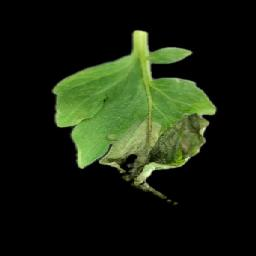

In [ ]:
# Permite visualizar una imagen específica (con iloc)
id = 0 # Indice de la imagen a cargar
image = load_image(data=df, index=id, root=ROOT_DIR)

#image.show() #popup option
image

Visualizando 10 imágenes aleatorias:
Imagen #1 (Índice: 1516):


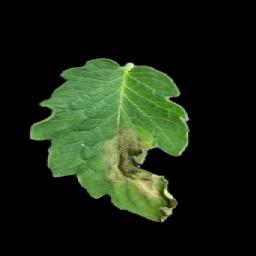

Imagen #2 (Índice: 45577):


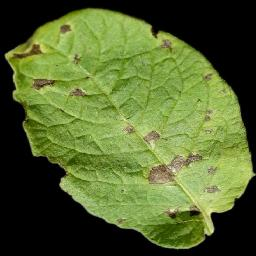

Imagen #3 (Índice: 34819):


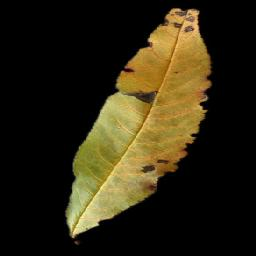

Imagen #4 (Índice: 18692):


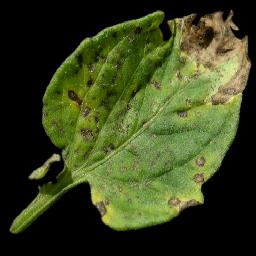

Imagen #5 (Índice: 46162):


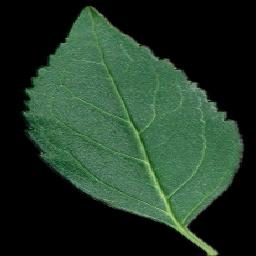

Imagen #6 (Índice: 22148):


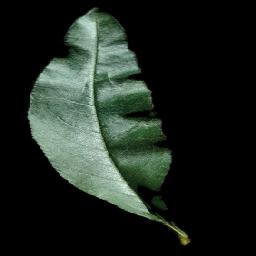

Imagen #7 (Índice: 39771):


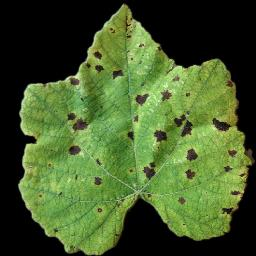

Imagen #8 (Índice: 5617):


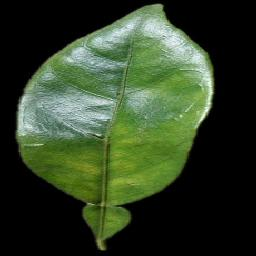

Imagen #9 (Índice: 11123):


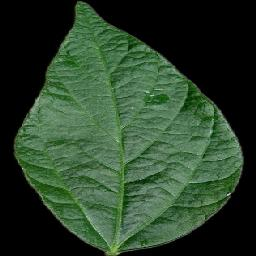

Imagen #10 (Índice: 34915):


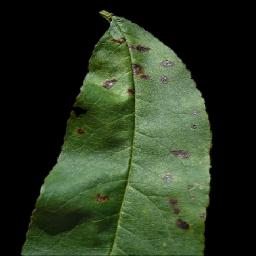

In [ ]:
import random

# Obtener 10 índices aleatorios del DataFrame
num_to_display = 10
random_indices = random.sample(range(len(df)), num_to_display)

print(f"Visualizando {num_to_display} imágenes aleatorias:")
for i, index in enumerate(random_indices):
    try:
        image = load_image(data=df, index=index, root=ROOT_DIR)
        print(f"Imagen #{i+1} (Índice: {index}):")
        display(image) # Muestra la imagen directamente en entornos como Jupyter Notebook
    except FileNotFoundError:
        print(f"Error: No se encontró la imagen en la ruta: {os.path.join(ROOT_DIR, df.loc[index, 'relative_path'])}")
    except Exception as e:
        print(f"Error al cargar la imagen en el índice {index}: {e}")

# Dataset split

#### Funciones

In [ ]:
import os, re

# Busca la carpeta raíz del dataset en el directorio donde fue descargado
def find_path(folder):
    match = re.search(fr"^(.*?)/{folder}/", DATASET_PATH)
    if match:
        prefix = match.group(1)
        path = os.path.join(prefix, f"{folder}/")
        return path
    else:
        print(f'No se ha podido encontrar la carpeta "{folder}" en {DATASET_PATH}')
        return None

In [ ]:
from sklearn.model_selection import train_test_split

def split_data(df,
               target_column='class',
               test_size=0.20,
               validation_size=0.0, # Por defecto no define un conjunto de validación
               random_state=42,     # Semilla para reproducibilidad
               split_column_name='split'):
    """
    Añade una columna al DataFrame indicando la división (train/test/validation).

    Realiza una división estratificada para mantener el balance de clases.

    Args:
        df (pd.DataFrame): DataFrame de entrada con al menos la columna 'target_column'.
        target_column (str): Nombre de la columna que contiene las etiquetas de clase
                             para la estratificación (ej: 'class').
        test_size (float): Proporción del dataset a incluir en el conjunto de test (ej: 0.20).
        validation_size (float): Proporción del dataset a incluir en el conjunto de validación.
                                 La proporción de entrenamiento será 1.0 - test_size - validation_size.
                                 Si es 0.0, solo se crearán conjuntos de train y test.
        random_state (int): Semilla para el generador de números aleatorios para asegurar
                            divisiones reproducibles.
        split_column_name (str): Nombre de la nueva columna que contendrá las etiquetas
                                 'train', 'test' o 'validation'.

    Returns:
        pd.DataFrame: El DataFrame original con la nueva columna 'split_column_name'.

    Raises:
        ValueError: Si test_size + validation_size >= 1.0, o si target_column no existe.
        ImportError: Si scikit-learn no está instalado.
    """
    if target_column not in df.columns:
        raise ValueError(f"La columna objetivo '{target_column}' no se encuentra en el DataFrame.")

    if not isinstance(test_size, float) or not (0.0 <= test_size < 1.0):
         raise ValueError("test_size debe ser un float entre 0.0 y 1.0.")

    if not isinstance(validation_size, float) or not (0.0 <= validation_size < 1.0):
         raise ValueError("validation_size debe ser un float entre 0.0 y 1.0.")

    if test_size + validation_size >= 1.0:
        raise ValueError("La suma de test_size y validation_size debe ser menor que 1.0.")

    # Crear la nueva columna inicializada (opcional, pero ayuda a la claridad)
    df[split_column_name] = 'unassigned'

    # Extraer etiquetas para estratificación
    labels = df[target_column]
    indices = df.index # Usaremos los índices para la división

    # --- Lógica de División ---

    # Caso 1: División en Train / Test (sin Validación)
    if validation_size == 0.0:
        train_indices, test_indices = train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            stratify=labels # Permite mantener el balance de clases
        )
        df.loc[train_indices, split_column_name] = 'train'
        df.loc[test_indices, split_column_name] = 'test'
        logging.info(f"División completada: Train ({1-test_size:.1%}), Test ({test_size:.1%}). Estratificada por '{target_column}'.")

    # Caso 2: División en Train / Test / Validation
    else:
        # Paso 1: Dividir en (Train + Validation) y Test
        remaining_indices, test_indices = train_test_split(
            indices,
            test_size=test_size, # Tamaño final del conjunto de test
            random_state=random_state,
            stratify=labels
        )

        # Calcular el tamaño relativo de validación respecto al conjunto restante (Train + Validation)
        # Ejemplo: test=0.2, val=0.1 -> Total 0.3. Restante 0.7. val_rel = 0.1 / 0.7 = 0.142...
        # train_test_split tomará el 14.2% del 70% restante, lo que equivale al 10% del total original.
        relative_val_size = validation_size / (1.0 - test_size)

        # Obtener las etiquetas correspondientes SOLO al conjunto restante para la segunda estratificación
        remaining_labels = df.loc[remaining_indices, target_column]

        # Paso 2: Dividir el conjunto restante en Train y Validation
        train_indices, validation_indices = train_test_split(
            remaining_indices, # Dividir solo los índices restantes
            test_size=relative_val_size, # Tamaño relativo calculado
            random_state=random_state,   # Usar la misma semilla para consistencia
            stratify=remaining_labels    # Estratificar usando las etiquetas restantes
        )

        # Asignar etiquetas de división al DataFrame original
        df.loc[train_indices, split_column_name] = 'train'
        df.loc[validation_indices, split_column_name] = 'valid'
        df.loc[test_indices, split_column_name] = 'test'

        train_actual_prop = len(train_indices) / len(df)
        val_actual_prop = len(validation_indices) / len(df)
        test_actual_prop = len(test_indices) / len(df)
        logging.info(f"División completada: Train ({train_actual_prop:.1%}), Validation ({val_actual_prop:.1%}), Test ({test_actual_prop:.1%}). Estratificada por '{target_column}'.")

    return df

In [ ]:
def dataset_already_exists(path_to_check: str) -> bool | None:
    """
    Verifica si el directorio especificado existe y está vacío.

    Args:
        path_to_check (str): Ruta del directorio a verificar.

    Returns:
        bool: True si el directorio existe y está vacío, False en caso contrario.
    """
    if not os.path.exists(path_to_check):
        # El directorio no existe -> Crea el directorio
        #print(f"☑️ El directorio no existe, aún no ha sido creado:\n > {path_to_check}") # Debugging
        return False # No realiza ninguna acción
    else:
        # Verificar si el directorio está vacío
        try:
            # Explora el contenido del directorio
            content = os.listdir(path_to_check)
            #print(content) # Debugging

            # Si el directorio está vacío, se puede eliminar directamente
            #       -> Elimina sin confirmación
            if not content:
                os.rmdir(path_to_check) # Elimina el directorio vacío
                print(f"☑️ El directorio estaba vacío y se ha eliminado de forma automática:\n > {path_to_check}\n")
                return False

            # Si el directorio contiene sólo archivos ocultos (de sistema)
            #       -> Elimina sin confirmación
            elif all([file.startswith('.') for file in content]):
                shutil.rmtree(path_to_check) # Elimina el directorio y su contenido
                print(f"☑️ El directorio sólo contenía archivos ocutlos, por lo que se ha eliminado de forma automática:\n > {path_to_check}\n")
                return False

            # Si hay archivos visibles en el directorio (dataset ya existe)
            #       -> Solicita permiso para eliminarlos
            else:
                # Input de confirmación del usuario
                confirmacion = input(f"⚠️ El directorio especificado ya existe y contiene archivos. ¿Deseas eliminar todo su contenido y el directorio en sí? [Y/N]: '{path_to_check}'").strip().lower()
                # Verifica la respuesta del usuario
                if confirmacion == 'y':
                    shutil.rmtree(path_to_check) # Elimina el directorio y su contenido
                    print(f"✅ El directorio y su contenido han sido eliminados exitosamente:\n > {path_to_check}\n")
                    return False
                else:
                    print(f"⛔️ La eliminación del directorio ha sido denegada por el usuario:\n  > {path_to_check}")
                    return True

        except OSError as e:
            print(f"❌ Error al eliminar el directorio vacío en {path_to_check}: {e}\n")
            return None
        except Exception as e:
            print(f"‼️ Ocurrió un error inesperado al intentar eliminar el directorio vacío en {path_to_check}: {e}\n")
            return None

In [ ]:
def create_ignore_function(df, train_label, filename_col='filename'):
    """
    Crea y devuelve la función 'ignore_files' que tiene acceso al DataFrame
    y sabe qué archivos mantener.
    """
    # Crea un conjunto (set) con los nombres de archivo que SÍ queremos copiar (ej: split == 'train')
    # Usa este conjunto para hacer la búsqueda de forma mucho más rápida
    files_to_keep = set(df[df['split'] == train_label][filename_col])
    #print(f"Archivos a mantener (split='{train_label}'): {files_to_keep}") # Debugging

    def ignore_files(current_dir, files_in_current_dir):
        """
        Función que será llamada por shutil.copytree.
        Decide qué archivos/directorios ignorar en el directorio actual.
        """
        ignore_list = []
        for item in files_in_current_dir:
            # Construye la ruta completa para verificar si es archivo o directorio
            full_path = os.path.join(current_dir, item)

            # Aplicar la lógica de ignorar SOLO los ARCHIVOS de la lista
            if os.path.isfile(full_path):
                # Si el nombre del archivo NO está en el conjunto de archivos a mantener,
                # entonces lo agrega a la lista de ignorados.
                if item not in files_to_keep:
                    # print(f"Ignorando archivo: {item} (en {current_dir})") # Debugging
                    ignore_list.append(item)

        # print(f"Directorio: {current_dir}, Ignorando: {ignore_list}") # Debugging
        return ignore_list

    # Devuelve la función 'ignore_files' configurada
    return ignore_files


## Divisón de datos

In [ ]:
# Disivión del dataset
# (Ejemplo: 80% train, 20% test)
try:
        df_split = split_data(df.copy(), # Usar .copy() para no modificar el original directamente aquí
                                target_column='class',
                                test_size=0.2,
                                random_state=42) # Usa la semilla que prefieras

except ValueError as e:
        print(f"\nError al dividir los datos: {e}")
except ImportError:
        print("\nError: La biblioteca scikit-learn no está instalada. Por favor, instálala con 'pip install scikit-learn'")
except Exception as e:
        print(f"\nOcurrió un error inesperado: {e}")


In [ ]:
df_split.sample(5)

,image_path,filename,class,group,tag,split
id,,,,,,
36578,Tomato___Target_Spot/,a440762c-221b-48b5-8c7b-892a2fa18db4___Com.G_T...,Tomato___Target_Spot,Tomato,Target_Spot,train
47437,Corn_(maize)___Common_rust_/,3f616e4b-2db0-48c7-96c4-87dfc0fb7d79___RS_Rust...,Corn_(maize)___Common_rust_,Corn_(maize),Common_rust_,test
12860,Soybean___healthy/,da00d784-ead9-4844-8c95-37b493a5b553___RS_HL 6...,Soybean___healthy,Soybean,healthy,train
11490,Soybean___healthy/,dd8e98a5-f355-427f-a901-d86f88e71ddb___RS_HL 6...,Soybean___healthy,Soybean,healthy,train
35725,Peach___Bacterial_spot/,6626b650-4fd0-485c-b8b6-22dfd2b2e3c0___Rut._Ba...,Peach___Bacterial_spot,Peach,Bacterial_spot,train


In [ ]:
df_split['split'].value_counts()

,count
split,
train,43444
test,10862


In [ ]:
# Guardamos el dataframe como .CSV para evitar realizar este proceso nuevamente
df_split.to_csv('dataframe_segmented_splitted.csv')

In [ ]:
print("\n--- Conteo de muestras por 'split' ---")
print(df_split['split'].value_counts(normalize=True)) # normalize=True muestra proporciones

print("\n--- Verificación del Balance de Clases por 'split' ---")

# Comprobar si las proporciones de clases son similares en cada split
print(df_split.groupby('split')['class'].value_counts(normalize=True))


--- Conteo de muestras por 'split' ---
split
train    0.799985
test     0.200015
Name: proportion, dtype: float64

--- Verificación del Balance de Clases por 'split' ---
split  class                                   
test   Orange___Haunglongbing_(Citrus_greening)    0.101455
       Tomato___Tomato_Yellow_Leaf_Curl_Virus      0.098693
       Soybean___healthy                           0.093721
       Peach___Bacterial_spot                      0.042349
       Tomato___Bacterial_spot                     0.039219
                                                     ...   
train  Tomato___Tomato_mosaic_virus                0.006859
       Raspberry___healthy                         0.006836
       Peach___healthy                             0.006629
       Apple___Cedar_apple_rust                    0.005064
       Potato___healthy                            0.002808
Name: proportion, Length: 76, dtype: float64


Se verifica que se conserva el balance original entre clases en el split de datos.

### Construcción de carpetas

In [ ]:
# Guarda directorio del dataset dividido
path = find_path("plantvillage-dataset")
SPLITTED_PATH = f"{path}splitted/" if path else None
SPLITTED_PATH

No se ha podido encontrar la carpeta "plantvillage-dataset" en /kaggle/input/plantvillage-dataset


In [ ]:
splits = df_split['split'].value_counts().index.tolist()
splits

['train', 'test']

In [ ]:
verfication = True # Ejecuta el proceso de verificación (punto 2)

print(f"Se inicia proceso de copiado del dataset…")
total_files = len(df_split) # Total de archivos del dataset
print(f" - Total de archivos en el dataset: {total_files}")

# Realiza el proceso de copiado de archivos para cada split
succeeded_process = True
for split in splits:
    # Crea las rutas de origen y destino
    # (Ejemplo: 'train', 'test', 'valid')
    print(f"\n\nIniciando proceso para '{split}' split …")
    source_folder = f'{ROOT_DIR}/'
    destination_folder = f'{SPLITTED_PATH}{split}/'
    total_split = len(df_split[df_split['split'] == split]) # Total de archivos del split
    if dataset_already_exists(destination_folder): # Verifica si el directorio existe y está vacío
        print("  ⨯ El directorio ya existe y contiene archivos, a petición del usuario se omite el proceso de copiado.")
        continue # Si el directorio ya existe, no se hace nada+
    else:
        print(f"🔄 Procesando split '{split.upper()}' ({(total_split/total_files*100):.2f}):")
        print(f"  - Total de archivos a copiar: {total_split}")
    succeeded = False

    try:
        print(f"1. Creando estructura de subcarpetas:")
        # 1. Crea la función para ignorar específica para el split a procesar
        ignore_function = create_ignore_function(df_split, train_label=split, filename_col='filename')
        print(f"    ✔ Función de filtro creada para el split ")

        # 2. Con copytree copia todo el "árbol" de directorios (careptas y subcarpetas)
        # Fitrando con ignore_function todos aquellos archivos que no pertenecen al split deseado
        print(f"    ∞ Copiando contenido del dataset (puede demorar hasta un minuto).")
        shutil.copytree(source_folder, destination_folder, ignore=ignore_function)
        print(f"    ✔ Proceso de copiado del split finalizado.")

        if verfication:
            # Verifica qué se haya copiado adecuadamente (opcional pero útil)
            print(f"2. Se inicia proceso de verificación…")
            copied_files = []
            for root, dirs, files_in_dest in os.walk(destination_folder):
                for name in files_in_dest:
                    copied_files.append(os.path.join(os.path.relpath(root, destination_folder), name).replace('\\', '/')) # Normalizar path
                    #print(f"  - {os.path.join(root, name)}") # Debuggin
            print(f"    ✔ Se crearon un total de {len(os.listdir(destination_folder))} carpetas (para las clases).")
            print(f"    ✔ Se copiaron un total de {len(copied_files)} archivos ({len(copied_files)/total_split*100:.2f}%)")
            # Agregar confirmación de igualdad cantidad split == copiados
            if len(copied_files) == total_split:
                print(f"✅ Se completó satisfactoriamente el subproceso de copiado para el split.\n")
                succeeded = True
            else:
                print(f" ❌ Error: No se pudo copiar correctamente el split '{split.upper()}'\n")
                succeeded = False
        else:
            succeeded = True # Si la verificación está desactivada, se asume que el proceso fue exitoso

    except FileExistsError:
        print(f"Error: La carpeta de destino '{destination_folder}' ya existe.\n")
        pass
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}\n")

    succeeded_process *= succeeded # Actualiza el estado del proceso
    # (Sólo es 'True' si todos los splits se copian correctamente)

if succeeded_process:
    print("\n\n🌟 El proceso de copiado del dataset ha finalizado con éxito.\n")
else:
    print("\n\n🚫 No se pudo completar satisfactoriamente el proceso de copiado del dataset.\nVerificar que se haya completado la eliminación de las carpetas.\n")

Se inicia proceso de copiado del dataset…
 - Total de archivos en el dataset: 54306


Iniciando proceso para 'train' split …
🔄 Procesando split 'TRAIN' (80.00):
  - Total de archivos a copiar: 43444
1. Creando estructura de subcarpetas:
    ✔ Función de filtro creada para el split 
    ∞ Copiando contenido del dataset (puede demorar hasta un minuto).
    ✔ Proceso de copiado del split finalizado.
2. Se inicia proceso de verificación…
    ✔ Se crearon un total de 38 carpetas (para las clases).
    ✔ Se copiaron un total de 43444 archivos (100.00%)
✅ Se completó satisfactoriamente el subproceso de copiado para el split.



Iniciando proceso para 'test' split …
🔄 Procesando split 'TEST' (20.00):
  - Total de archivos a copiar: 10862
1. Creando estructura de subcarpetas:
    ✔ Función de filtro creada para el split 
    ∞ Copiando contenido del dataset (puede demorar hasta un minuto).
    ✔ Proceso de copiado del split finalizado.
2. Se inicia proceso de verificación…
    ✔ Se crearon un t

----
# Training model

## Dataloader

In [ ]:
import tensorflow as tf

In [ ]:
# Data laoders setup
def load_from_directory(data_folder):
    """
    Carga un dataset de imágenes desde un directorio específico.

    Args:
        data_folder (str): Ruta al directorio que contiene las imágenes.

    Returns:
        tf.data.Dataset: Dataset de TensorFlow con las imágenes y etiquetas.
    """
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_folder,  # Ruta al directorio de datos
        labels="inferred",  # Las etiquetas se infieren automáticamente desde los nombres de las carpetas
        label_mode="categorical",  # Las etiquetas se codifican como categorías (one-hot encoding)
        class_names=None,  # Las clases se detectan automáticamente
        color_mode="rgb",  # Las imágenes se cargan en modo RGB
        batch_size=128,  # Tamaño de lote para el entrenamiento
        image_size=(256, 256),  # Redimensiona las imágenes a 128x128 píxeles
        shuffle=True,  # Mezcla las imágenes aleatoriamente
        seed=42,  # No se utiliza una semilla específica para la aleatorización
        validation_split=None,  # No se realiza una división de validación aquí
        subset=None,  # No se especifica un subconjunto (train/validation)
        interpolation="bilinear",  # Método de interpolación para redimensionar las imágenes
        follow_links=False,  # No sigue enlaces simbólicos
        crop_to_aspect_ratio=False  # No recorta las imágenes para ajustar la relación de aspecto
    )

    return dataset

In [ ]:
# Carga el dataset de imágenes desde el directorio especificado
train_images = ""; test_images = ""; valid_images = ""

print("Cargando datasets desde el directorio…\n")
for split in splits:
    data_folder = f'{SPLITTED_PATH}{split}/'

    # Carga el conjunto de datos desde el directorio especificado
    # Utiliza la función de TensorFlow para crear un dataset de imágenes
    match split:
        case 'train':
            print(f"Cargando dataset de entrenamiento desde:\n > {data_folder}")
            train_images = load_from_directory(data_folder)
        case 'test':
            print(f"Cargando dataset de test desde:\n > {data_folder}")
            test_images = load_from_directory(data_folder)
        case 'valid':
            print(f"Cargando dataset de validación desde:\n > {data_folder}")
            valid_images = load_from_directory(data_folder)
        case _: # En caso de no coincidir con ninguno de los splits
            print(f"⚠️ El split '{split}' no es reconocido. No se cargará ningún dataset.")
            continue # Salta al siguiente split
    print(f"✅ Dataset cargado exitosamente.\n")

Cargando datasets desde el directorio…

Cargando dataset de entrenamiento desde:
 > Nonetrain/
Found 43444 files belonging to 38 classes.
✅ Dataset cargado exitosamente.

Cargando dataset de test desde:
 > Nonetest/
Found 10862 files belonging to 38 classes.
✅ Dataset cargado exitosamente.



In [ ]:
print("Resumen de los datasets cargados:")
print(f" - Total de imágenes en el dataset de entrenamiento: {len(train_images)}")
print(f" - Total de imágenes en el dataset de validación: {len(valid_images)}")
print(f" - Total de imágenes en el dataset de test: {len(test_images)}")
print(f"Total de imágenes cargadas: {len(train_images) + len(test_images) + len(valid_images)}\n")

Resumen de los datasets cargados:
 - Total de imágenes en el dataset de entrenamiento: 340
 - Total de imágenes en el dataset de validación: 0
 - Total de imágenes en el dataset de test: 85
Total de imágenes cargadas: 425



In [ ]:
print(f"Clases detectadas:")
[print(" -",clase) for clase in train_images.class_names]
print(f"Total de clases: {len(train_images.class_names)}")

Clases detectadas:
 - Apple___Apple_scab
 - Apple___Black_rot
 - Apple___Cedar_apple_rust
 - Apple___healthy
 - Blueberry___healthy
 - Cherry_(including_sour)___Powdery_mildew
 - Cherry_(including_sour)___healthy
 - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 - Corn_(maize)___Common_rust_
 - Corn_(maize)___Northern_Leaf_Blight
 - Corn_(maize)___healthy
 - Grape___Black_rot
 - Grape___Esca_(Black_Measles)
 - Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
 - Grape___healthy
 - Orange___Haunglongbing_(Citrus_greening)
 - Peach___Bacterial_spot
 - Peach___healthy
 - Pepper,_bell___Bacterial_spot
 - Pepper,_bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Raspberry___healthy
 - Soybean___healthy
 - Squash___Powdery_mildew
 - Strawberry___Leaf_scorch
 - Strawberry___healthy
 - Tomato___Bacterial_spot
 - Tomato___Early_blight
 - Tomato___Late_blight
 - Tomato___Leaf_Mold
 - Tomato___Septoria_leaf_spot
 - Tomato___Spider_mites Two-spotted_spider_mite
 

----
## Arquitectura del modelo

In [ ]:
from tensorflow.keras import datasets, layers, models
from tensorflow.keras import Input

model = models.Sequential()

# Bloque 1
model.add(Input(shape=(256, 256, 3)))
model.add(layers.Rescaling(1./255))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.1))

# Bloque 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.1))

# Bloque 3
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.1))

# Bloque 4
model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.1))

model.add(layers.Flatten())

# Capa densa intermedia
model.add(layers.Dense(512, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))
model.add(layers.Dropout(0.25))

# Capa de salida con 38 neuronas y softmax para multiclase
model.add(layers.Dense(38, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,102,502 (99.57 MB)

 Trainable params: 26,100,518 (99.57 MB)

 Non-trainable params: 1,984 (7.75 KB)

## Entrenamiento

In [ ]:
import time

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

start_time = time.perf_counter()

# Definimos el callback para guardar el mejor modelo según la métrica elegida
checkpoint_callback = ModelCheckpoint(
    filepath='best_model.keras',   # Se generará una carpeta con este nombre
    monitor='val_loss',            # Métrica a monitorear ('val_accuracy' es otra opción)
    save_best_only=True,           # Guarda solo si hay mejora
    save_weights_only=False,       # Guarda la arquitectura + pesos
    verbose=1
)

# Ajusta el modelo a tu criterio
with tf.device('/GPU:0'):
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

history = model.fit(
    train_images,
    validation_data=test_images,
    epochs=10,
    callbacks=[checkpoint_callback]  # Incorporamos el callback
)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Tiempo de entrenamiento: {elapsed_time:.2f} segundos")

Epoch 1/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.5794 - loss: 1.6470
Epoch 1: val_loss improved from inf to 10.64083, saving model to best_model.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 155s 375ms/step - accuracy: 0.5797 - loss: 1.6454 - val_accuracy: 0.0368 - val_loss: 10.6408
Epoch 2/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.8615 - loss: 0.4601
Epoch 2: val_loss improved from 10.64083 to 1.55166, saving model to best_model.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 104s 305ms/step - accuracy: 0.8615 - loss: 0.4599 - val_accuracy: 0.6369 - val_loss: 1.5517
Epoch 3/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9248 - loss: 0.2432
Epoch 3: val_loss improved from 1.55166 to 0.52972, saving model to best_model.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 106s 312ms/step - accuracy: 0.9248 - loss: 0.2431 - val_accuracy: 0.8463 - val_loss: 0.5297
Epoch 4/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9495 - loss: 0.1615
Epoch 4: val_loss improved from

## Guardando resultados

In [ ]:
#Recording History in json & pickle
import json
with open('training_hist.json','w') as f:
  json.dump(history.history,f)

import pickle
with open('training_hist.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [ ]:
import os

experiment = 'experimento_segmented' # Completar número de experimento
files = ['best_model.keras','training_hist.json','training_hist.pkl']
destino=f"/content/drive/MyDrive/CV2-PlantVillage/{experiment}/"

def check_folder(folder):
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"Folder '{folder}' created successfully.")
    else:
        print(f"Folder '{folder}' already exists.")

check_folder(destino)

for file in files:
    try:
        origen=f"/content/{file}"
        !cp -r "$origen" "$destino"
    except:
        print(f"Error al copiar el archivo '{file}'")
    finally:
        print(f"Archivo '{file}' copiado exitosamente.")

Folder '/content/drive/MyDrive/CV2-PlantVillage/experimento_segmented/' created successfully.
Archivo 'best_model.keras' copiado exitosamente.
Archivo 'training_hist.json' copiado exitosamente.
Archivo 'training_hist.pkl' copiado exitosamente.


---
# Gráficos

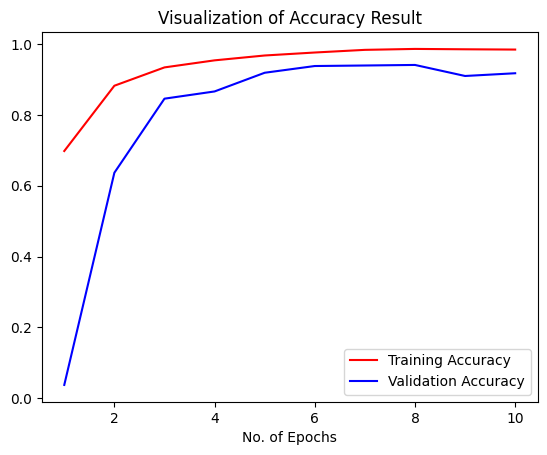

In [ ]:
import matplotlib.pyplot as plt

epochs = [i for i in range(1,11)]
plt.plot(epochs,history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [ ]:
#Validation set Accuracy
model = tf.keras.models.load_model('best_model.keras')
val_loss, val_acc = model.evaluate(test_images)
print('Validation accuracy:', val_acc)

85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.9380 - loss: 0.2161
Validation accuracy: 0.9401583671569824


# Re-Entrenamiento

Dado que al ver los resultados del entrenamiento anterior se confirma que continuar por más épocas puede ser beneficioso, se vuelve a entrenar por otras 10 epochs.

In [59]:

# Load the previously saved model
model = tf.keras.models.load_model('best_model.keras')


start_time = time.perf_counter()

# Continue training from the last epoch
with tf.device('/GPU:0'):
    history = model.fit(
        train_images,
        validation_data=test_images,
        epochs=20, # Continue training for 10 more epochs
        initial_epoch=10, # Start from epoch 11
        callbacks=[checkpoint_callback]
    )

end_time = time.perf_counter()
elapsed2_time = end_time - start_time
total_elapsed_time = elapsed2_time + elapsed_time
print(f"Se retomó el entrenamiento por otros: {elapsed2_time:.2f} segundos")
print(f"Tiempo de entrenamiento total: {total_elapsed_time:.2f} segundos")

Epoch 11/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9854 - loss: 0.0442
Epoch 11: val_loss did not improve from 0.21075
340/340 ━━━━━━━━━━━━━━━━━━━━ 120s 327ms/step - accuracy: 0.9854 - loss: 0.0442 - val_accuracy: 0.9383 - val_loss: 0.2206
Epoch 12/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9812 - loss: 0.0597
Epoch 12: val_loss did not improve from 0.21075
340/340 ━━━━━━━━━━━━━━━━━━━━ 106s 311ms/step - accuracy: 0.9812 - loss: 0.0598 - val_accuracy: 0.8951 - val_loss: 0.3677
Epoch 13/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9794 - loss: 0.0624
Epoch 13: val_loss did not improve from 0.21075
340/340 ━━━━━━━━━━━━━━━━━━━━ 106s 311ms/step - accuracy: 0.9794 - loss: 0.0624 - val_accuracy: 0.9061 - val_loss: 0.3499
Epoch 14/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9890 - loss: 0.0330
Epoch 14: val_loss did not improve from 0.21075
340/340 ━━━━━━━━━━━━━━━━━━━━ 142s 311ms/step - accuracy: 0.9890 - loss: 0.0330 - val_accu

## Guardando resultados

In [60]:
#Recording History in json & pickle
import json
with open('training_hist2.json','w') as f:
  json.dump(history.history,f)

import pickle
with open('training_hist2.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [61]:
import os

experiment = 'experimento_segmented2' # Completar número de experimento
files = ['best_model.keras','training_hist.json','training_hist.pkl']
destino=f"/content/drive/MyDrive/CV2-PlantVillage/{experiment}/"

def check_folder(folder):
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"Folder '{folder}' created successfully.")
    else:
        print(f"Folder '{folder}' already exists.")

check_folder(destino)

for file in files:
    try:
        origen=f"/content/{file}"
        !cp -r "$origen" "$destino"
    except:
        print(f"Error al copiar el archivo '{file}'")
    finally:
        print(f"Archivo '{file}' copiado exitosamente.")

Folder '/content/drive/MyDrive/CV2-PlantVillage/experimento_segmented2/' created successfully.
Archivo 'best_model.keras' copiado exitosamente.
Archivo 'training_hist.json' copiado exitosamente.
Archivo 'training_hist.pkl' copiado exitosamente.


---
# Gráficos

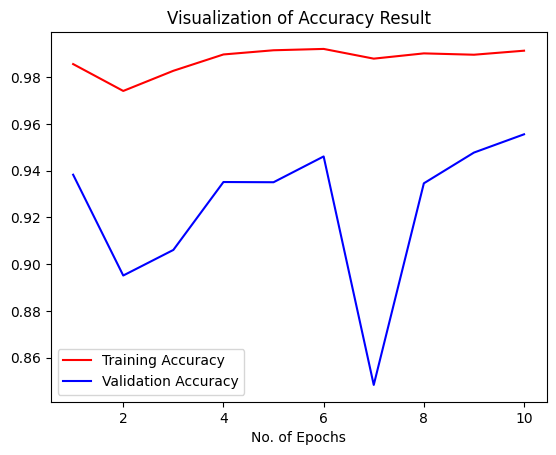

In [62]:
import matplotlib.pyplot as plt

epochs = [i for i in range(1,11)]
plt.plot(epochs,history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [63]:
#Validation set Accuracy
model = tf.keras.models.load_model('best_model.keras')
val_loss, val_acc = model.evaluate(test_images)
print('Validation accuracy:', val_acc)

85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9556 - loss: 0.1672
Validation accuracy: 0.9556251168251038
